# LFW: Classical ML vs Dense Neural Networks vs CNNs

This notebook directly compares **classical machine-learning models, dense neural networks, and convolutional neural networks** for Labeled Faces in the Wild (LFW) person identification. The comparison also evaluates whether PCA-based feature reduction improves classical and dense models, and whether deeper convolutional architectures provide an advantage on this dataset.

### Main comparisons
- Classical models on raw pixels vs PCA features
- Classical ML vs dense neural networks
- Dense networks on raw pixels vs PCA features
- Compact CNN vs deeper VGG-style CNN
- Image-space CNNs vs CNNs applied to reshaped PCA features

### Methods covered
- K-Nearest Neighbors
- Random Forest
- Multinomial Naive Bayes
- Decision Tree
- Logistic Regression
- Support Vector Classifier
- PCA feature reduction
- Dense neural networks
- Convolutional neural networks
- VGG-style convolutional networks
- Experimental CNNs applied to reshaped PCA features

The goal is to compare how feature engineering and learned representations affect image classification.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten

In [2]:
def plot_results(history):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

    ax[0].plot(history.history["accuracy"], label="train")
    ax[0].plot(history.history["val_accuracy"], label="validation")
    ax[0].set_title("Accuracy")
    ax[0].legend()

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="validation")
    ax[1].set_title("Loss")
    ax[1].legend()

    plt.show()


def evaluate_classifiers(models, model_names, X_train, y_train, X_test, y_test):
    accuracies = []

    for model_class, name in zip(models, model_names):
        print("Evaluating", name)
        model = model_class()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        accuracies.append(acc)
        print("Accuracy = {:.4f}".format(acc))

    best = int(np.argmax(accuracies))
    print("\nBest model:", model_names[best])
    print("Accuracy = {:.4f}".format(accuracies[best]))

    return accuracies

## 2. Load and inspect LFW

In [3]:
lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=0.5)

X_flat = lfw_people.data.astype("float32") / 255.0
X_images = np.expand_dims(lfw_people.images.astype("float32") / 255.0, -1)
y = lfw_people.target

target_names = lfw_people.target_names
n_classes = len(target_names)

print("People:")
for name in target_names:
    print("-", name)

print("\nFlat feature matrix:", X_flat.shape)
print("Image tensor:", X_images.shape)
print("Classes:", n_classes)

People:
- Ariel Sharon
- Colin Powell
- Donald Rumsfeld
- George W Bush
- Gerhard Schroeder
- Hugo Chavez
- Jacques Chirac
- Jean Chretien
- John Ashcroft
- Junichiro Koizumi
- Serena Williams
- Tony Blair

Flat feature matrix: (1560, 2914)
Image tensor: (1560, 62, 47, 1)
Classes: 12


## 3. Classical Models on Raw Pixels

In [4]:
X_train_flat, X_test_flat, y_train_int, y_test_int = train_test_split(
    X_flat,
    y,
    test_size=0.25,
    random_state=4361,
    stratify=y,
)

models = [
    KNeighborsClassifier,
    RandomForestClassifier,
    MultinomialNB,
    DecisionTreeClassifier,
    LogisticRegression,
    SVC,
]

model_names = [
    "K-Nearest Neighbors",
    "Random Forest",
    "Multinomial Naive Bayes",
    "Decision Tree",
    "Logistic Regression",
    "Support Vector Classifier",
]

raw_pixel_accuracies = evaluate_classifiers(
    models,
    model_names,
    X_train_flat,
    y_train_int,
    X_test_flat,
    y_test_int,
)

Evaluating K-Nearest Neighbors
Accuracy = 0.5077
Evaluating Random Forest
Accuracy = 0.5513
Evaluating Multinomial Naive Bayes
Accuracy = 0.3410
Evaluating Decision Tree
Accuracy = 0.3564
Evaluating Logistic Regression
Accuracy = 0.3410
Evaluating Support Vector Classifier
Accuracy = 0.6590

Best model: Support Vector Classifier
Accuracy = 0.6590


### Reference result

A prior run of this experiment produced **0.7333 accuracy** for the best raw-pixel classical model, the Support Vector Classifier.

## 4. Classical Models: Raw Pixels vs PCA Features

PCA compresses the high-dimensional pixel vectors into 72 whitened components before classification.

In [5]:
n_components = 72

pca = PCA(
    n_components=n_components,
    svd_solver="randomized",
    whiten=True,
    random_state=42,
)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Original training shape:", X_train_flat.shape)
print("PCA training shape:", X_train_pca.shape)
print("PCA test shape:", X_test_pca.shape)

Original training shape: (1170, 2914)
PCA training shape: (1170, 72)
PCA test shape: (390, 72)


In [6]:
pca_models = [
    KNeighborsClassifier,
    RandomForestClassifier,
    DecisionTreeClassifier,
    LogisticRegression,
    SVC,
]

pca_model_names = [
    "K-Nearest Neighbors",
    "Random Forest",
    "Decision Tree",
    "Logistic Regression",
    "Support Vector Classifier",
]

pca_accuracies = evaluate_classifiers(
    pca_models,
    pca_model_names,
    X_train_pca,
    y_train_int,
    X_test_pca,
    y_test_int,
)

Evaluating K-Nearest Neighbors
Accuracy = 0.6538
Evaluating Random Forest
Accuracy = 0.5231
Evaluating Decision Tree
Accuracy = 0.3128
Evaluating Logistic Regression
Accuracy = 0.7385
Evaluating Support Vector Classifier
Accuracy = 0.7846

Best model: Support Vector Classifier
Accuracy = 0.7846


### Reference result

With 72 PCA components, a prior run reached **0.7974 accuracy** with the Support Vector Classifier, improving on the raw-pixel classical baseline.

## 5. Classical ML vs Dense Neural Network on Raw Pixels

In [7]:
y_train_oh = tf.keras.utils.to_categorical(y_train_int, n_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test_int, n_classes)


def dense_model(inputs, hidden_1=500, hidden_2=500, target=10):
    model = Sequential([
        Input(shape=(inputs,)),
        Dense(hidden_1, activation="relu"),
        Dense(hidden_2, activation="relu"),
        Dense(target, activation="softmax"),
    ])
    return model


dense_network = dense_model(
    inputs=X_train_flat.shape[1],
    target=n_classes,
)

dense_network.summary()

dense_network.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │     1,457,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         6,012 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,714,012 (6.54 MB)

 Trainable params: 1,714,012 (6.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2923 - loss: 2.4399 - val_accuracy: 0.3410 - val_loss: 2.3261
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3393 - loss: 2.2346 - val_accuracy: 0.3410 - val_loss: 2.1375
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3393 - loss: 2.1598 - val_accuracy: 0.3410 - val_loss: 2.1582
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1353 - val_accuracy: 0.3410 - val_loss: 2.1289
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1408 - val_accuracy: 0.3410 - val_loss: 2.1423
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3393 - loss: 2.1367 - val_accuracy: 0.3410 - val_loss: 2.1224
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3393 - loss: 2.1233 - val_accuracy: 0.3410 - val_loss: 2.1249
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3393 - loss: 2.1241 - val_accuracy: 0.3410 - val_loss: 

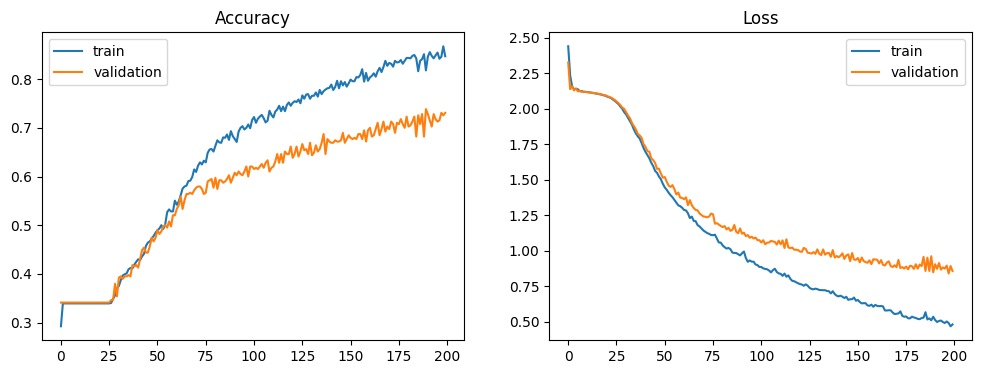

In [8]:
history_dense = dense_network.fit(
    X_train_flat,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_flat, y_test_oh),
)

print("Final training accuracy: {:.4f}".format(history_dense.history["accuracy"][-1]))
print("Final validation accuracy: {:.4f}".format(history_dense.history["val_accuracy"][-1]))

plot_results(history_dense)

A prior run of this dense raw-pixel model ended near **0.5179 validation accuracy**.

## 6. Dense Network: Raw Pixels vs PCA Features

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │        36,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         6,012 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293,012 (1.12 MB)

 Trainable params: 293,012 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2726 - loss: 2.2466 - val_accuracy: 0.4000 - val_loss: 1.9185
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5026 - loss: 1.7168 - val_accuracy: 0.5333 - val_loss: 1.6336
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6051 - loss: 1.3072 - val_accuracy: 0.5744 - val_loss: 1.3353
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7376 - loss: 0.9515 - val_accuracy: 0.6949 - val_loss: 1.0985
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8487 - loss: 0.6742 - val_accuracy: 0.7385 - val_loss: 0.9282
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8949 - loss: 0.4802 - val_accuracy: 0.7641 - val_loss: 0.8282
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9291 - loss: 0.3498 - val_accuracy: 0.7821 - val_loss: 0.7707
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9462 - loss: 0.2562 - val_accuracy: 0.7795 - val_loss: 

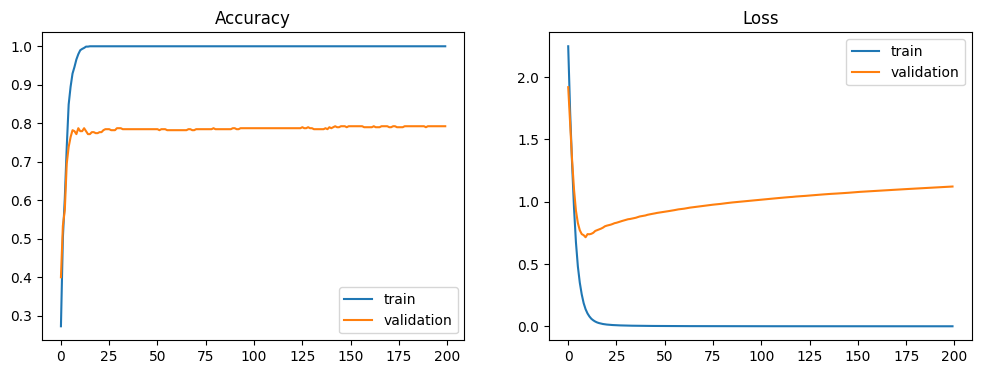

In [9]:
dense_pca = dense_model(
    inputs=X_train_pca.shape[1],
    target=n_classes,
)

dense_pca.summary()

dense_pca.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_dense_pca = dense_pca.fit(
    X_train_pca,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_pca, y_test_oh),
)

print("Final training accuracy: {:.4f}".format(history_dense_pca.history["accuracy"][-1]))
print("Final validation accuracy: {:.4f}".format(history_dense_pca.history["val_accuracy"][-1]))

plot_results(history_dense_pca)

A prior run of the PCA + dense-network configuration reached **0.8231 validation accuracy**.

## 7. Dense Network vs Convolutional Neural Network

In [10]:
X_train_img, X_test_img, y_train_img_int, y_test_img_int = train_test_split(
    X_images,
    y,
    test_size=0.25,
    random_state=4361,
    stratify=y,
)

y_train_img_oh = tf.keras.utils.to_categorical(y_train_img_int, n_classes)
y_test_img_oh = tf.keras.utils.to_categorical(y_test_img_int, n_classes)

print("Training images:", X_train_img.shape)
print("Training labels:", y_train_img_oh.shape)


def cnn_model(input_shape, target):
    return Sequential([
        Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(target, activation="softmax"),
    ])


cnn = cnn_model(
    input_shape=X_train_img.shape[1:],
    target=n_classes,
)

cnn.summary()

cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Training images: (1170, 62, 47, 1)
Training labels: (1170, 12)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 47, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10560)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12)             │       126,732 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,548 (568.55 KB)

 Trainable params: 145,548 (568.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 905ms/step - accuracy: 0.3265 - loss: 2.4637 - val_accuracy: 0.3410 - val_loss: 2.3755
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3393 - loss: 2.2795 - val_accuracy: 0.3410 - val_loss: 2.1498
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3393 - loss: 2.1690 - val_accuracy: 0.3410 - val_loss: 2.1452
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3393 - loss: 2.1413 - val_accuracy: 0.3410 - val_loss: 2.1477
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3393 - loss: 2.1496 - val_accuracy: 0.3410 - val_loss: 2.1344
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3393 - loss: 2.1375 - val_accuracy: 0.3410 - val_loss: 2.1358
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3393 - loss: 2.1374 - val_accuracy: 0.3410 - val_loss: 2.1295
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3393 - loss: 2.1341 - val_accuracy: 0.3410 - val_loss

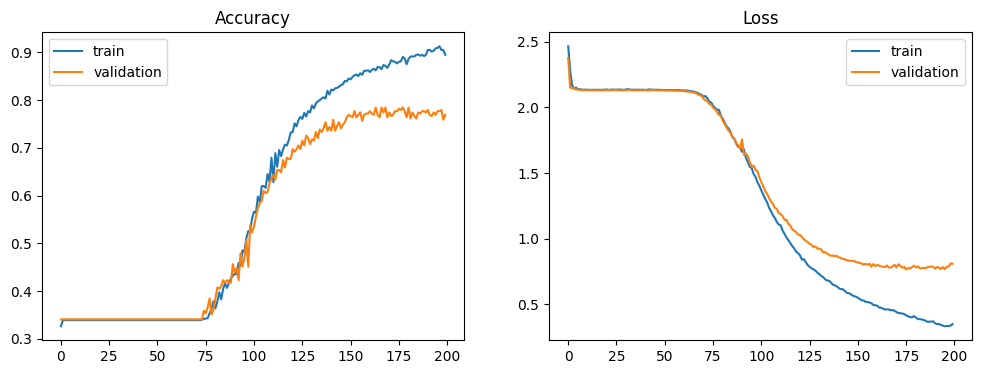

In [11]:
history_cnn = cnn.fit(
    X_train_img,
    y_train_img_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_img, y_test_img_oh),
)

print("Final training accuracy: {:.4f}".format(history_cnn.history["accuracy"][-1]))
print("Final validation accuracy: {:.4f}".format(history_cnn.history["val_accuracy"][-1]))

plot_results(history_cnn)

A prior run of this compact CNN ended near **0.5179 validation accuracy**.

## 8. Compact CNN vs Deeper VGG-Style CNN

In [12]:
def vgg3(input_shape, target):
    return Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), padding="same", activation="relu"),
        Conv2D(32, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), padding="same", activation="relu"),
        Conv2D(64, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), padding="same", activation="relu"),
        Conv2D(128, (3, 3), padding="same", activation="relu"),

        Flatten(),
        Dense(128, activation="relu"),
        Dense(target, activation="softmax"),
    ])


vgg_lfw = vgg3(
    input_shape=X_train_img.shape[1:],
    target=n_classes,
)

vgg_lfw.summary()

vgg_lfw.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 47, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 47, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 31, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21120)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     2,703,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,991,468 (11.41 MB)

 Trainable params: 2,991,468 (11.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3000 - loss: 2.3807 - val_accuracy: 0.3410 - val_loss: 2.1509
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3393 - loss: 2.1740 - val_accuracy: 0.3410 - val_loss: 2.1344
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3393 - loss: 2.1516 - val_accuracy: 0.3410 - val_loss: 2.1688
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3393 - loss: 2.1717 - val_accuracy: 0.3410 - val_loss: 2.1349
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3393 - loss: 2.1651 - val_accuracy: 0.3410 - val_loss: 2.1310
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3393 - loss: 2.1447 - val_accuracy: 0.3410 - val_loss: 2.1403
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3393 - loss: 2.1353 - val_accuracy: 0.3410 - val_loss: 2.1410
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3393 - loss: 2.1435 - val_accuracy: 0.3410 - val_loss: 

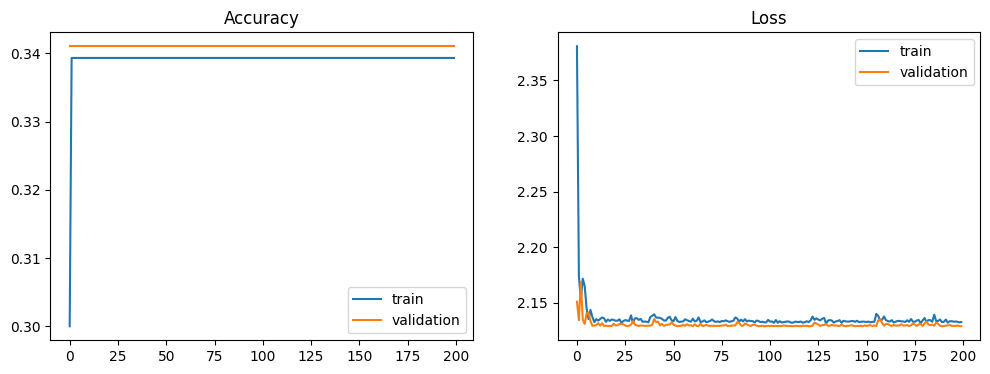

In [13]:
history_vgg = vgg_lfw.fit(
    X_train_img,
    y_train_img_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_img, y_test_img_oh),
)

print("Final training accuracy: {:.4f}".format(history_vgg.history["accuracy"][-1]))
print("Final validation accuracy: {:.4f}".format(history_vgg.history["val_accuracy"][-1]))

plot_results(history_vgg)

A prior run of this deeper image-space model ended near **0.3564 validation accuracy**.

## 9. Image-Space CNNs vs CNNs on Reshaped PCA Features

This experiment reshapes the 72 PCA components into a `9 × 8 × 1` tensor and applies convolutional models. This is useful as a representation experiment, but the reshaped PCA components do **not** preserve the original image's spatial neighborhood structure.

In [14]:
X_train_pca_map = X_train_pca.reshape(-1, 9, 8, 1)
X_test_pca_map = X_test_pca.reshape(-1, 9, 8, 1)

print("PCA feature maps:", X_train_pca_map.shape, X_test_pca_map.shape)

PCA feature maps: (1170, 9, 8, 1) (390, 9, 8, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 9, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,900 (85.55 KB)

 Trainable params: 21,900 (85.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 898ms/step - accuracy: 0.1872 - loss: 2.4256 - val_accuracy: 0.3410 - val_loss: 2.1699
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.1917 - val_accuracy: 0.3410 - val_loss: 2.1530
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.1767 - val_accuracy: 0.3410 - val_loss: 2.1330
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.1494 - val_accuracy: 0.3410 - val_loss: 2.1311
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.1302 - val_accuracy: 0.3410 - val_loss: 2.1095
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.1073 - val_accuracy: 0.3410 - val_loss: 2.0969
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.0867 - val_accuracy: 0.3410 - val_loss: 2.0822
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3393 - loss: 2.0620 - val_accuracy: 0.3410 - val_loss

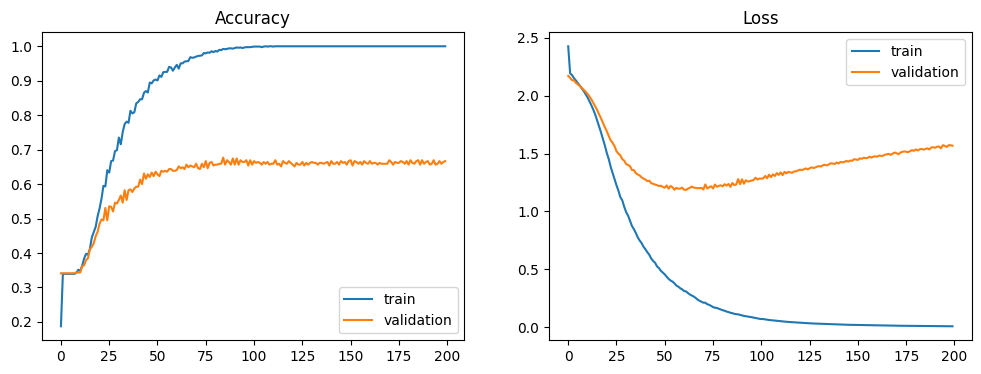

In [15]:
cnn_pca = cnn_model(
    input_shape=X_train_pca_map.shape[1:],
    target=n_classes,
)

cnn_pca.summary()

cnn_pca.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_cnn_pca = cnn_pca.fit(
    X_train_pca_map,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_pca_map, y_test_oh),
)

plot_results(history_cnn_pca)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 9, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 9, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,644 (1.35 MB)

 Trainable params: 353,644 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.2838 - loss: 2.3915 - val_accuracy: 0.3410 - val_loss: 2.1828
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1879 - val_accuracy: 0.3410 - val_loss: 2.1454
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1656 - val_accuracy: 0.3410 - val_loss: 2.1423
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1544 - val_accuracy: 0.3410 - val_loss: 2.1263
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1354 - val_accuracy: 0.3410 - val_loss: 2.1217
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1245 - val_accuracy: 0.3410 - val_loss: 2.1169
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.1091 - val_accuracy: 0.3410 - val_loss: 2.0866
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3393 - loss: 2.0710 - val_accuracy: 0.3410 - val_loss: 

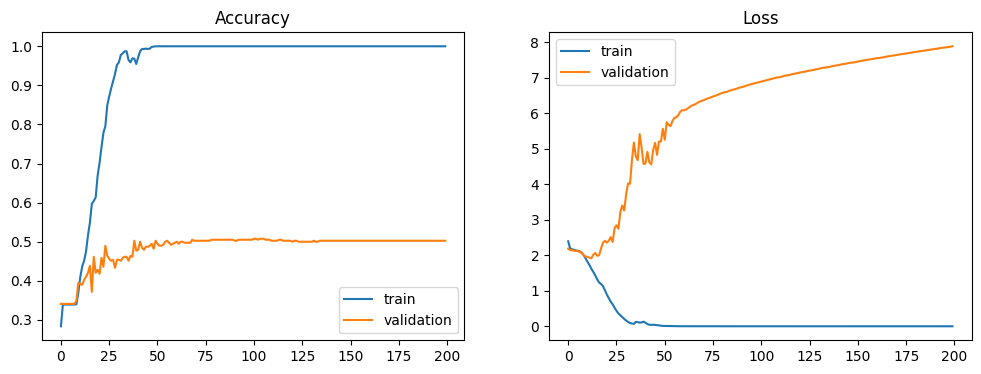

In [16]:
vgg_pca = vgg3(
    input_shape=X_train_pca_map.shape[1:],
    target=n_classes,
)

vgg_pca.summary()

vgg_pca.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_vgg_pca = vgg_pca.fit(
    X_train_pca_map,
    y_train_oh,
    epochs=200,
    batch_size=256,
    verbose=1,
    validation_data=(X_test_pca_map, y_test_oh),
)

plot_results(history_vgg_pca)

Prior runs reached approximately **0.7231 validation accuracy** for the compact CNN on reshaped PCA features and **0.5769** for the VGG-style version.

## 10. Model Comparison Summary

The LFW experiments show that the best representation depends on the model. PCA substantially strengthened the classical SVC and the dense network in the observed runs, while the direct CNN variants did not automatically outperform the feature-based approaches on this relatively small face-identification dataset.